# Start with data import and preprocessing

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vafaeii/kth-action-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kth-action-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/kth-action-recognition-dataset


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm # Good practice for progress bars
import torch.nn as nn
from torch.utils.data import random_split
import cv2 # Open CV for processing video data
import pathlib

ROOT_DIR = path

In [ ]:
# Use a GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


# Preprocess the Data

### We can start by counting the samples in each class

In [ ]:
import pathlib
dataset_root_path = pathlib.Path(ROOT_DIR)

for path in dataset_root_path.glob("*"):
    print(f"{path.name}: {len(list(path.glob('*.avi')))}")

walking: 100
running: 100
00sequences.txt: 0
boxing: 100
handclapping: 99
handwaving: 100
jogging: 100


# we need to parse the 00sequences.txt files to extract the motion frames accurately

In [ ]:
"""
Reads the sequence annotation file and extracts frame index ranges
for each video/sample.

Returns:
    dict: A dictionary where keys are sequence names and values are
    lists of (start_frame, end_frame) tuples.
"""

def parse_sequence_file(filepath):
    sequences = {}

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Skip lines that don't contain 'frames' as the second token
            parts = line.split()
            if len(parts) < 3 or parts[1] != 'frames':
                continue

            name = parts[0]
            ranges_str = ' '.join(parts[2:])

            segments = []
            for r in ranges_str.split(','):
                r = r.strip()
                if '-' not in r:
                    continue
                start, end = r.split('-')
                segments.append((int(start), int(end)))

            sequences[name] = segments

    return sequences

sequences = parse_sequence_file(dataset_root_path / '00sequences.txt')
print(sequences['person01_boxing_d1'])

[(1, 95), (96, 185), (186, 245), (246, 360)]


In [ ]:
all_video_file_paths = (
    list(dataset_root_path.glob("handwaving/*.avi"))
    + list(dataset_root_path.glob("running/*.avi"))
    + list(dataset_root_path.glob("boxing/*.avi"))
    + list(dataset_root_path.glob("handclapping/*.avi"))
    + list(dataset_root_path.glob("walking/*.avi"))
    + list(dataset_root_path.glob("jogging/*.avi"))
 )

In [ ]:

# Iterate over (video_path, segment) pairs
samples = []
for path in all_video_file_paths:
    lookup_name = path.stem.replace('_uncomp', '')
    if lookup_name in sequences:
        for segment in sequences[lookup_name]:
            samples.append((path, segment))

print(f"Total samples: {len(samples)}")

Total samples: 2391


Extract class labels based on the parent folder name of each file

In [ ]:
class_labels = sorted({path.parent.name for path in all_video_file_paths})
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}

print(f"Unique classes: {list(label2id.keys())}")

Unique classes: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']


# Some brief EDA to explore the data and its distribution

In [ ]:
segment_lengths = []
# The samples dictionary is now iterable, so its easy to check the distribution of segments
for path, (start, end) in samples:
    segment_lengths.append(end - start)

print("Segment statistics:")
print(f"Number of segments: {len(segment_lengths)}")
print(f"Average length: {np.mean(segment_lengths):.2f} frames")
print(f"Minimum length: {np.min(segment_lengths)} frames")
print(f"Maximum length: {np.max(segment_lengths)} frames")

Segment statistics:
Number of segments: 2391
Average length: 94.21 frames
Minimum length: 23 frames
Maximum length: 361 frames


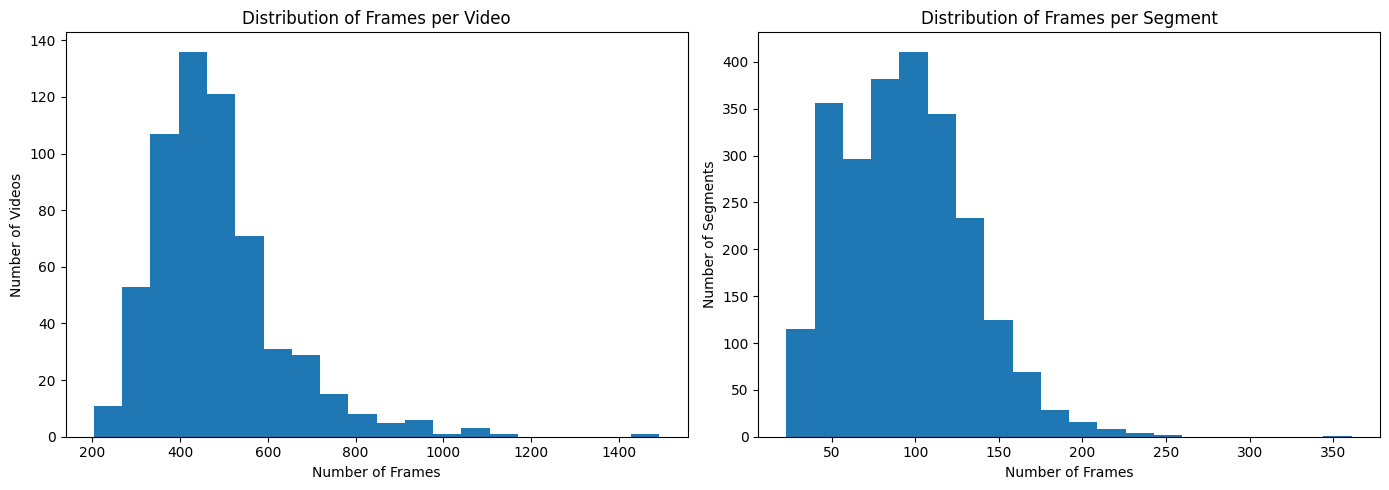

In [ ]:
frame_counts = []
for video_path in all_video_file_paths:
    vid = cv2.VideoCapture(str(video_path))
    frame_counts.append(int(vid.get(cv2.CAP_PROP_FRAME_COUNT)))
    vid.release()

segment_lengths = [end - start for _, (start, end) in samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(frame_counts, bins=20)
axes[0].set_xlabel("Number of Frames")
axes[0].set_ylabel("Number of Videos")
axes[0].set_title("Distribution of Frames per Video")

axes[1].hist(segment_lengths, bins=20)
axes[1].set_xlabel("Number of Frames")
axes[1].set_ylabel("Number of Segments")
axes[1].set_title("Distribution of Frames per Segment")

plt.tight_layout()
plt.show()

A box plot will reveal the outliers more clearly

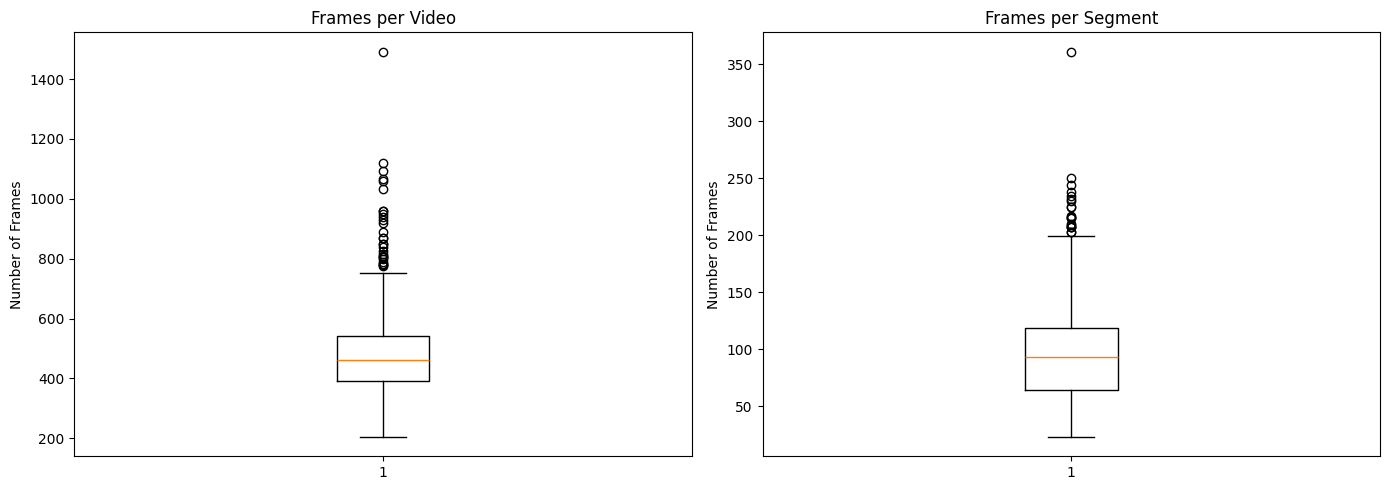

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(frame_counts)
axes[0].set_ylabel("Number of Frames")
axes[0].set_title("Frames per Video")

axes[1].boxplot(segment_lengths)
axes[1].set_ylabel("Number of Frames")
axes[1].set_title("Frames per Segment")

plt.tight_layout()
plt.show()

# Import the model

- EfficientNet comes with size varieties from b0 to b7, where the number of parameters increase, with a scaling factor of:
  - **width**: number of layers
  - **height**: number of channels per layer
  - **resolution**: expected input image size

  Original source [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/pdf/1905.11946)

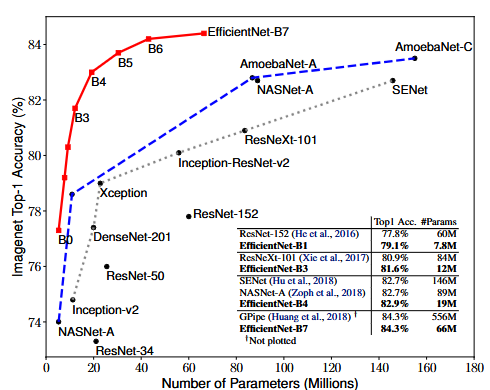

We can check the configuration of the weights for the b0 model, to get an idea of the expected input configs

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
weights = EfficientNet_B0_Weights.DEFAULT # Load the pretrained EfficientNet-B0 weights

# Extract the preprocessing pipeline that these weights expect
# (resize to 256, center crop to 224, normalize with ImageNet stats)
transform = weights.transforms()
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [ ]:
persons = sorted({path.stem.replace('_uncomp', '').split('_')[0] for path in all_video_file_paths})
print(f"Number of persons: {len(persons)}")
print(persons)

Number of persons: 25
['person01', 'person02', 'person03', 'person04', 'person05', 'person06', 'person07', 'person08', 'person09', 'person10', 'person11', 'person12', 'person13', 'person14', 'person15', 'person16', 'person17', 'person18', 'person19', 'person20', 'person21', 'person22', 'person23', 'person24', 'person25']


## Split the data

We split the data based on persons to prevent data leakage, with 80% for training (of which 20% are for validaiton) and 20% for testing

In [ ]:
train_persons = {'person11', 'person12', 'person13', 'person14', 'person15', 'person16', 'person17', 'person18', 'person04', 'person10', 'person01', 'person09', 'person01', 'person08', 'person25', 'person07'}
val_persons   = {'person19', 'person20', 'person21', 'person23', 'person24'}
test_persons  = {'person22', 'person02', 'person03', 'person05', 'person06'}

train_samples = [(p, s) for p, s in samples if p.stem.replace('_uncomp', '').split('_')[0] in train_persons]
val_samples   = [(p, s) for p, s in samples if p.stem.replace('_uncomp', '').split('_')[0] in val_persons]
test_samples  = [(p, s) for p, s in samples if p.stem.replace('_uncomp', '').split('_')[0] in test_persons]

print(f"Train: {len(train_samples)} segments")
print(f"Val: {len(val_samples)} segments")
print(f"Test: {len(test_samples)} segments")

Train: 1432 segments
Val: 480 segments
Test: 479 segments


Since we want to feed the data into the CNN architecture using the DataLoader, we need to prepare the data with a custom class

There isn't a class in torch that I have found that handles videos, so we can do this with openCV, the goal is to prepare a tensor of the shape (nr_frames, channels, height, width)

In [ ]:
cap = cv2.VideoCapture(str(all_video_file_paths[0]))
ret, frame = cap.read()
cap.release()

print(f"Raw frame shape: {frame.shape}")  # (height, width, channels)

Raw frame shape: (120, 160, 3)


This is a potential problem or incompatability of efficientNet and the dataset:
- EfficientNet expects 224, 224 so this would mean upscaling the raw data to fit the expected input shape

- This is where mobileNet might work better?

Following this documentation on preparing the custom Dataset: https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html


The Dataset class is an abstract class that needs to be inherited by our custom class, and then we override the given functions without tasks requirements

In [ ]:
class VideoDataset(Dataset):
    def __init__(self, samples, label2id, transform, num_frames=16):
        self.samples = samples
        self.label2id = label2id
        self.transform = transform
        self.num_frames = num_frames # how many frames we sample per segment (cropped video clip)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, (start, end) = self.samples[idx]
        label = self.label2id[path.parent.name]

        # Sample num_frames evenly within the segment
        cap = cv2.VideoCapture(str(path))
        indices = np.linspace(start, end, self.num_frames, dtype=int)

        frames = []
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
              # Reuse last successfully read frame instead of skipping
              if frames:
                  frames.append(frames[-1])
              continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = torch.from_numpy(frame).permute(2, 0, 1) # efficientNet transform expects a tensor (or PIL Image) (H, W, 3) → (3, H, W)
            frames.append(frame)
        cap.release()

        tensor = torch.stack([self.transform(f) for f in frames])
        return tensor, label  # [num_frames, 3, 224, 224], int

Now we can create the DataLoader

In [ ]:
train_dataset = VideoDataset(train_samples, label2id, transform, num_frames=16)
val_dataset   = VideoDataset(val_samples,   label2id, transform, num_frames=16)
test_dataset  = VideoDataset(test_samples,  label2id, transform, num_frames=16)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

frames, labels = next(iter(train_loader))
print(f"Frames shape: {frames.shape}")
print(f"Labels shape: {labels.shape}")

Frames shape: torch.Size([8, 16, 3, 224, 224])
Labels shape: torch.Size([8])


# Built the model

In [ ]:
class ActionRecognitionModel(nn.Module):
    def __init__(self, num_classes, hidden_size=512, num_layers=1):
        super(ActionRecognitionModel, self).__init__()

        # Load pretrained EfficientNet-B0
        efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # Freeze all layers
        for param in efficientnet.parameters():
            param.requires_grad = False

        # Unfreeze the last block
        for param in efficientnet.features[8].parameters():
            param.requires_grad = True

        # Remove the classifier head, keep only the feature extractor
        self.cnn = efficientnet.features
        self.pool = efficientnet.avgpool  # global average pooling → (batch, 1280, 1, 1)

        # LSTM
        self.lstm = nn.LSTM(input_size=1280, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)

        # Classifier
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: [batch, num_frames, 3, 224, 224]
        batch_size, num_frames, C, H, W = x.shape

        # Reshape to process all frames through CNN at once
        x = x.view(batch_size * num_frames, C, H, W) # [batch*frames, 3, 224, 224]
        x = self.cnn(x) # [batch*frames, 1280, 7, 7]
        x = self.pool(x) # [batch*frames, 1280, 1, 1]
        x = x.view(batch_size, num_frames, -1) # [batch, frames, 1280]

        # LSTM over the sequence of frame features
        _, (h_n, _) = self.lstm(x) # h_n: [1, batch, hidden_size]

        # Classify from final hidden state
        out = self.classifier(h_n.squeeze(0)) # [batch, num_classes]
        return out

In [ ]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - trainable

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {frozen:,}")

Total parameters:     7,684,738
Trainable parameters: 4,089,350
Frozen parameters:    3,595,388


Ill write a custom training and test loop

In [ ]:
def train(epoch, model):
    model.train()
    for batch_idx, (frames, labels) in enumerate(train_loader):
        frames, labels = frames.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(frames)
        loss = loss_fn (output, labels)
        loss.backward()
        optimizer.step()

        if batch_idx % 10 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(frames), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

In [ ]:
accuracy_list = []
loss_list = []

def test(model):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)

            output = model(frames)
            test_loss += loss_fn (output, labels).item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(labels.data.view_as(pred)).cpu().sum().item()

    test_loss /= len(val_loader.dataset)
    accuracy = 100. * correct / len(val_loader.dataset)
    accuracy_list.append(accuracy)
    loss_list.append(test_loss)
    print('\nVal set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(val_loader.dataset), accuracy))

In [ ]:
CONFIG = {
    'num_epochs': 5,
    'batch_size': 8,
    'lr': 0.001,
    'num_frames': 16,
    'hidden_size': 512,
    'num_layers': 1,
    'num_classes': len(label2id),
}

# Setup model for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ActionRecognitionModel(num_classes=CONFIG['num_classes'], hidden_size=CONFIG['hidden_size'], num_layers=CONFIG['num_layers']).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

print(f"Device: {device}")
print('Number of trainable parameters: {}'.format(
    sum(p.numel() for p in model.parameters() if p.requires_grad)))

Device: cuda
Number of trainable parameters: 4089350


In [ ]:
for epoch in range(1, CONFIG['num_epochs'] + 1):
    train(epoch, model)
    test(model)

Train Epoch: 1 [0/1432 (0%)]	Loss: 1.810888
Train Epoch: 1 [80/1432 (6%)]	Loss: 1.613278
Train Epoch: 1 [160/1432 (11%)]	Loss: 1.193555
Train Epoch: 1 [240/1432 (17%)]	Loss: 1.100853
Train Epoch: 1 [320/1432 (22%)]	Loss: 1.057584
Train Epoch: 1 [400/1432 (28%)]	Loss: 0.859611
Train Epoch: 1 [480/1432 (34%)]	Loss: 0.842581
Train Epoch: 1 [560/1432 (39%)]	Loss: 0.978059
Train Epoch: 1 [640/1432 (45%)]	Loss: 0.898476
Train Epoch: 1 [720/1432 (50%)]	Loss: 0.677094
Train Epoch: 1 [800/1432 (56%)]	Loss: 0.777941
Train Epoch: 1 [880/1432 (61%)]	Loss: 1.087966
Train Epoch: 1 [960/1432 (67%)]	Loss: 0.999219
Train Epoch: 1 [1040/1432 (73%)]	Loss: 0.962035
Train Epoch: 1 [1120/1432 (78%)]	Loss: 0.560664
Train Epoch: 1 [1200/1432 (84%)]	Loss: 0.816714
Train Epoch: 1 [1280/1432 (89%)]	Loss: 0.690840
Train Epoch: 1 [1360/1432 (95%)]	Loss: 0.451334

Val set: Average loss: 0.0984, Accuracy: 279/480 (58%)

Train Epoch: 2 [0/1432 (0%)]	Loss: 0.751855
Train Epoch: 2 [80/1432 (6%)]	Loss: 0.860857
Train Ep

# Next we can finally evaluate the model

              precision    recall  f1-score   support

      boxing       0.97      0.97      0.97        79
handclapping       0.80      0.94      0.86        80
  handwaving       0.90      0.76      0.82        80
     jogging       0.58      0.62      0.60        80
     running       0.74      0.66      0.70        80
     walking       0.86      0.86      0.86        80

    accuracy                           0.80       479
   macro avg       0.81      0.80      0.80       479
weighted avg       0.81      0.80      0.80       479



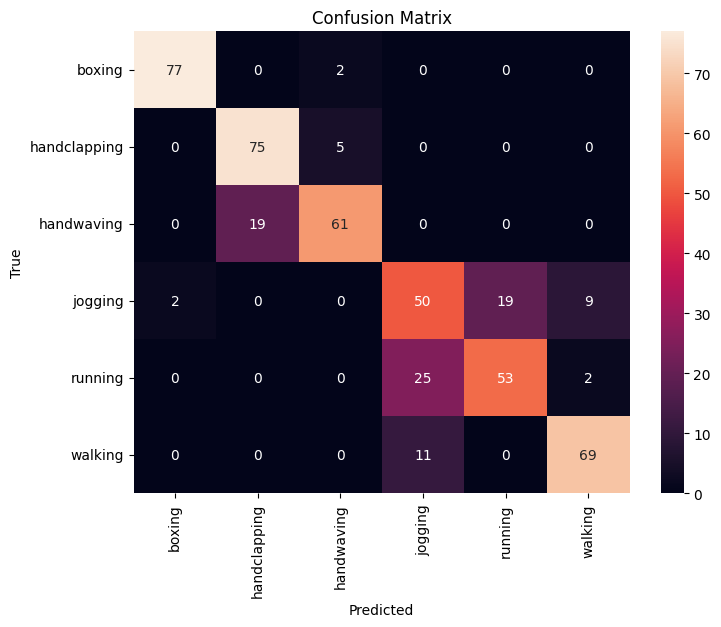

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for frames, labels in loader:
            frames, labels = frames.to(device), labels.to(device)
            output = model(frames)
            preds = output.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Get predictions on test set
true_labels, pred_labels = get_predictions(model, test_loader, device)

# Classification report
print(classification_report(true_labels, pred_labels, target_names=list(label2id.keys())))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label2id.keys(), yticklabels=label2id.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()